In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("\n" + "="*100)
print("CELL 1: LIGHTGBM ON ORIGINAL DATASET")
print("="*100)

print("\n📂 Loading original dataset...")
original_df = pd.read_csv('imu_dataset_original.csv')

print(f"\n📊 DATASET INFORMATION:")
print(f"   Total Rows:     {len(original_df):,}")
print(f"   Columns:        {list(original_df.columns)}")
print(f"   Memory Usage:   {original_df.memory_usage().sum() / 1024**2:.2f} MB")

print(f"\n🌍 TERRAIN DISTRIBUTION:")
terrain_dist = original_df['Terrain'].value_counts().sort_index()
for terrain, count in terrain_dist.items():
    pct = (count / len(original_df)) * 100
    print(f"   {terrain:15} : {count:6,} samples ({pct:5.2f}%)")

print("\n🔧 PREPARING DATA...")
X_orig = original_df.drop(['Terrain', 'Terrain_Label', 'time'], axis=1)
y_orig = original_df['Terrain_Label']

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

print(f"   Training samples: {len(X_train_orig):,}")
print(f"   Test samples:     {len(X_test_orig):,}")
print(f"   Features:         {X_orig.shape[1]}")

print("\n🚀 TRAINING LIGHTGBM MODEL...")
model_orig = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

model_orig.fit(X_train_orig, y_train_orig)
print("   ✓ Training complete!")

print("\n📊 MAKING PREDICTIONS...")
y_pred_orig = model_orig.predict(X_test_orig)
y_pred_proba_orig = model_orig.predict_proba(X_test_orig)

acc_orig = accuracy_score(y_test_orig, y_pred_orig)
prec_orig = precision_score(y_test_orig, y_pred_orig, average='weighted', zero_division=0)
recall_orig = recall_score(y_test_orig, y_pred_orig, average='weighted', zero_division=0)
f1_orig = f1_score(y_test_orig, y_pred_orig, average='weighted', zero_division=0)

confidence_orig = np.max(y_pred_proba_orig, axis=1)
avg_confidence_orig = np.mean(confidence_orig)
min_confidence_orig = np.min(confidence_orig)
max_confidence_orig = np.max(confidence_orig)
std_confidence_orig = np.std(confidence_orig)

cm_orig = confusion_matrix(y_test_orig, y_pred_orig)
class_report_orig = classification_report(y_test_orig, y_pred_orig, output_dict=True)

print("\n" + "="*100)
print("📈 ORIGINAL DATASET - PERFORMANCE METRICS")
print("="*100)

print(f"\n{'Metric':<25} {'Value':>20} {'Percentage':>20}")
print("-" * 65)
print(f"{'Accuracy':<25} {acc_orig:>20.6f} {acc_orig*100:>19.2f}%")
print(f"{'Precision (Weighted)':<25} {prec_orig:>20.6f} {prec_orig*100:>19.2f}%")
print(f"{'Recall (Weighted)':<25} {recall_orig:>20.6f} {recall_orig*100:>19.2f}%")
print(f"{'F1-Score (Weighted)':<25} {f1_orig:>20.6f}")

print(f"\n{'CONFIDENCE METRICS':<25}")
print("-" * 65)
print(f"{'Average Confidence':<25} {avg_confidence_orig:>20.6f} {avg_confidence_orig*100:>19.2f}%")
print(f"{'Min Confidence':<25} {min_confidence_orig:>20.6f}")
print(f"{'Max Confidence':<25} {max_confidence_orig:>20.6f}")
print(f"{'Std Dev Confidence':<25} {std_confidence_orig:>20.6f}")

print("\n" + "="*100)
print("📊 ORIGINAL DATASET - PER-CLASS METRICS (BY TERRAIN)")
print("="*100)
print(classification_report(y_test_orig, y_pred_orig, 
                          target_names=['ASPHALT', 'CONCRETE', 'DIRT_ROAD', 'PLOUGHED', 'UNPLOUGHED']))

print("\n✅ CELL 1 COMPLETE!")


CELL 1: LIGHTGBM ON ORIGINAL DATASET

📂 Loading original dataset...

📊 DATASET INFORMATION:
   Total Rows:     98,035
   Columns:        ['time', 'wx', 'wy', 'wz', 'ax', 'ay', 'az', 'Terrain', 'Terrain_Label']
   Memory Usage:   6.73 MB

🌍 TERRAIN DISTRIBUTION:
   ASPHALT         : 57,010 samples (58.15%)
   CONCRETE        :  6,719 samples ( 6.85%)
   DIRT_ROAD       :  4,044 samples ( 4.13%)
   PLOUGHED        : 15,693 samples (16.01%)
   UNPLOUGHED      : 14,569 samples (14.86%)

🔧 PREPARING DATA...
   Training samples: 78,428
   Test samples:     19,607
   Features:         6

🚀 TRAINING LIGHTGBM MODEL...
   ✓ Training complete!

📊 MAKING PREDICTIONS...

📈 ORIGINAL DATASET - PERFORMANCE METRICS

Metric                                   Value           Percentage
-----------------------------------------------------------------
Accuracy                              0.724741               72.47%
Precision (Weighted)                  0.700614               70.06%
Recall (Weighted)   

In [6]:
print("\n\n" + "="*100)
print("CELL 2: LIGHTGBM ON AUGMENTED DATASET")
print("="*100)

print("\n📂 Loading augmented dataset...")
augmented_df = pd.read_csv('augmented_dataset.csv')

print(f"\n📊 DATASET INFORMATION:")
print(f"   Total Rows:     {len(augmented_df):,}")
print(f"   Columns:        {list(augmented_df.columns)}")
print(f"   Memory Usage:   {augmented_df.memory_usage().sum() / 1024**2:.2f} MB")

print(f"\n🌍 TERRAIN DISTRIBUTION:")
terrain_dist_aug = augmented_df['Terrain'].value_counts().sort_index()
for terrain, count in terrain_dist_aug.items():
    pct = (count / len(augmented_df)) * 100
    print(f"   {terrain:15} : {count:6,} samples ({pct:5.2f}%)")

print("\n🔧 PREPARING DATA...")
X_aug = augmented_df.drop(['Terrain', 'Terrain_Label', 'time'], axis=1)
y_aug = augmented_df['Terrain_Label']

X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

print(f"   Training samples: {len(X_train_aug):,}")
print(f"   Test samples:     {len(X_test_aug):,}")
print(f"   Features:         {X_aug.shape[1]}")

print("\n🚀 TRAINING LIGHTGBM MODEL...")
model_aug = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

model_aug.fit(X_train_aug, y_train_aug)
print("   ✓ Training complete!")

print("\n📊 MAKING PREDICTIONS...")
y_pred_aug = model_aug.predict(X_test_aug)
y_pred_proba_aug = model_aug.predict_proba(X_test_aug)

acc_aug = accuracy_score(y_test_aug, y_pred_aug)
prec_aug = precision_score(y_test_aug, y_pred_aug, average='weighted', zero_division=0)
recall_aug = recall_score(y_test_aug, y_pred_aug, average='weighted', zero_division=0)
f1_aug = f1_score(y_test_aug, y_pred_aug, average='weighted', zero_division=0)

confidence_aug = np.max(y_pred_proba_aug, axis=1)
avg_confidence_aug = np.mean(confidence_aug)
min_confidence_aug = np.min(confidence_aug)
max_confidence_aug = np.max(confidence_aug)
std_confidence_aug = np.std(confidence_aug)

cm_aug = confusion_matrix(y_test_aug, y_pred_aug)
class_report_aug = classification_report(y_test_aug, y_pred_aug, output_dict=True)

print("\n" + "="*100)
print("📈 AUGMENTED DATASET - PERFORMANCE METRICS")
print("="*100)

print(f"\n{'Metric':<25} {'Value':>20} {'Percentage':>20}")
print("-" * 65)
print(f"{'Accuracy':<25} {acc_aug:>20.6f} {acc_aug*100:>19.2f}%")
print(f"{'Precision (Weighted)':<25} {prec_aug:>20.6f} {prec_aug*100:>19.2f}%")
print(f"{'Recall (Weighted)':<25} {recall_aug:>20.6f} {recall_aug*100:>19.2f}%")
print(f"{'F1-Score (Weighted)':<25} {f1_aug:>20.6f}")

print(f"\n{'CONFIDENCE METRICS':<25}")
print("-" * 65)
print(f"{'Average Confidence':<25} {avg_confidence_aug:>20.6f} {avg_confidence_aug*100:>19.2f}%")
print(f"{'Min Confidence':<25} {min_confidence_aug:>20.6f}")
print(f"{'Max Confidence':<25} {max_confidence_aug:>20.6f}")
print(f"{'Std Dev Confidence':<25} {std_confidence_aug:>20.6f}")

print("\n" + "="*100)
print("📊 AUGMENTED DATASET - PER-CLASS METRICS (BY TERRAIN)")
print("="*100)
print(classification_report(y_test_aug, y_pred_aug, 
                          target_names=['ASPHALT', 'CONCRETE', 'DIRT_ROAD', 'PLOUGHED', 'UNPLOUGHED']))

print("\n✅ CELL 2 COMPLETE!")



CELL 2: LIGHTGBM ON AUGMENTED DATASET

📂 Loading augmented dataset...

📊 DATASET INFORMATION:
   Total Rows:     147,052
   Columns:        ['time', 'wx', 'wy', 'wz', 'ax', 'ay', 'az', 'Terrain', 'Terrain_Label']
   Memory Usage:   10.10 MB

🌍 TERRAIN DISTRIBUTION:
   ASPHALT         : 85,560 samples (58.18%)
   CONCRETE        : 10,077 samples ( 6.85%)
   DIRT_ROAD       :  6,078 samples ( 4.13%)
   PLOUGHED        : 23,536 samples (16.01%)
   UNPLOUGHED      : 21,801 samples (14.83%)

🔧 PREPARING DATA...
   Training samples: 117,641
   Test samples:     29,411
   Features:         6

🚀 TRAINING LIGHTGBM MODEL...
   ✓ Training complete!

📊 MAKING PREDICTIONS...

📈 AUGMENTED DATASET - PERFORMANCE METRICS

Metric                                   Value           Percentage
-----------------------------------------------------------------
Accuracy                              0.709224               70.92%
Precision (Weighted)                  0.685965               68.60%
Recall (Weigh



CELL 3: PER-TERRAIN ACCURACY COMPARISON

📊 CREATING VISUALIZATIONS...


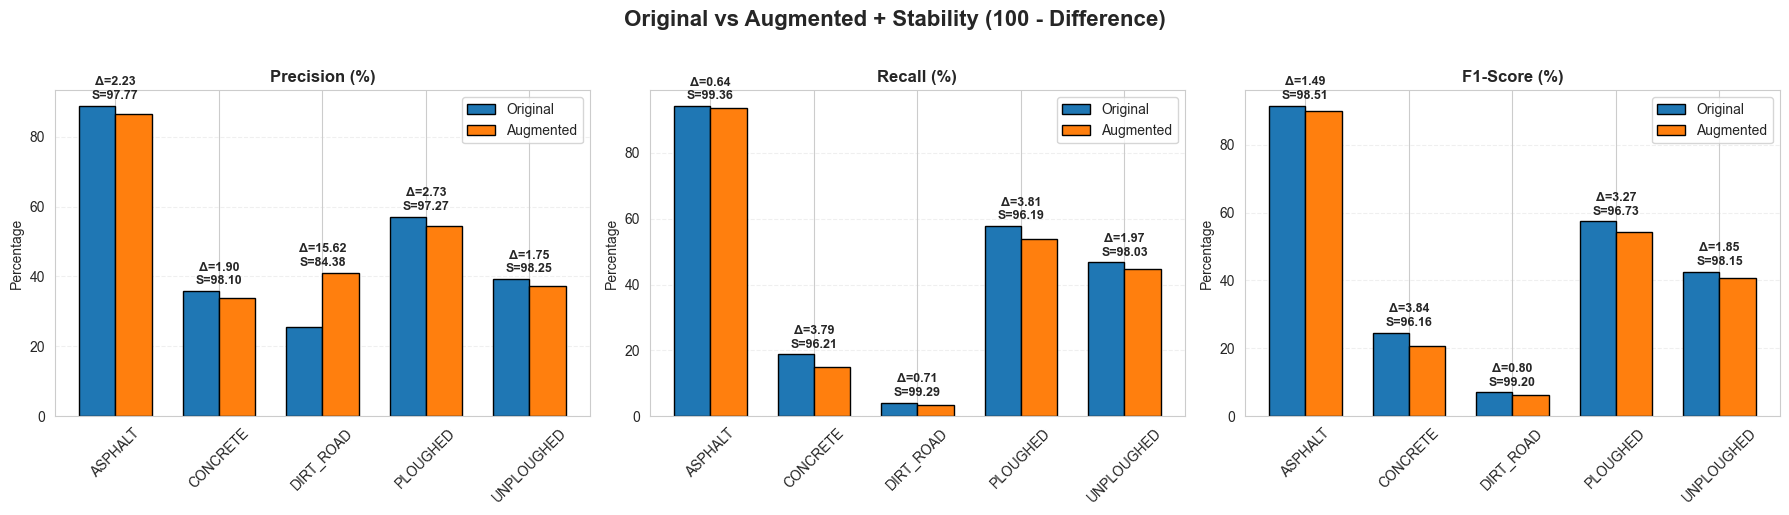

✅ CELL 3 COMPLETE!


In [16]:
print("\n\n" + "="*100)
print("CELL 3: PER-TERRAIN ACCURACY COMPARISON")
print("="*100)

terrain_names = ['ASPHALT', 'CONCRETE', 'DIRT_ROAD', 'PLOUGHED', 'UNPLOUGHED']

comparison_data = []

for class_idx in range(5):
    terrain_name = terrain_names[class_idx]
    
    prec_o = class_report_orig[str(class_idx)]['precision']
    recall_o = class_report_orig[str(class_idx)]['recall']
    f1_o = class_report_orig[str(class_idx)]['f1-score']
    
    prec_a = class_report_aug[str(class_idx)]['precision']
    recall_a = class_report_aug[str(class_idx)]['recall']
    f1_a = class_report_aug[str(class_idx)]['f1-score']
    
    prec_o_pct = prec_o * 100
    prec_a_pct = prec_a * 100
    recall_o_pct = recall_o * 100
    recall_a_pct = recall_a * 100
    f1_o_pct = f1_o * 100
    f1_a_pct = f1_a * 100

    prec_diff = abs(prec_o_pct - prec_a_pct)
    recall_diff = abs(recall_o_pct - recall_a_pct)
    f1_diff = abs(f1_o_pct - f1_a_pct)

    prec_stability = 100 - prec_diff
    recall_stability = 100 - recall_diff
    f1_stability = 100 - f1_diff
    
    comparison_data.append({
        'Terrain': terrain_name,
        'Precision_Orig': prec_o_pct,
        'Precision_Aug': prec_a_pct,
        'Precision_Stability': prec_stability,
        'Recall_Orig': recall_o_pct,
        'Recall_Aug': recall_a_pct,
        'Recall_Stability': recall_stability,
        'F1_Orig': f1_o_pct,
        'F1_Aug': f1_a_pct,
        'F1_Stability': f1_stability
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n📊 CREATING VISUALIZATIONS...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Original vs Augmented + Stability (100 - Difference)', 
             fontsize=16, fontweight='bold', y=1.02)

terrains = df_comparison['Terrain'].values
x = np.arange(len(terrains))
width = 0.35

# PRECISION
ax = axes[0]
orig = df_comparison['Precision_Orig'].values
aug = df_comparison['Precision_Aug'].values

bars1 = ax.bar(x - width/2, orig, width, label='Original', edgecolor='black')
bars2 = ax.bar(x + width/2, aug, width, label='Augmented', edgecolor='black')

for i in range(len(x)):
    diff = abs(orig[i] - aug[i])
    stability = 100 - diff
    ax.text(x[i], max(orig[i], aug[i]) + 2,
            f"Δ={diff:.2f}\nS={stability:.2f}",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Precision (%)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xticks(x)
ax.set_xticklabels(terrains, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

# RECALL
ax = axes[1]
orig = df_comparison['Recall_Orig'].values
aug = df_comparison['Recall_Aug'].values

bars1 = ax.bar(x - width/2, orig, width, label='Original', edgecolor='black')
bars2 = ax.bar(x + width/2, aug, width, label='Augmented', edgecolor='black')

for i in range(len(x)):
    diff = abs(orig[i] - aug[i])
    stability = 100 - diff
    ax.text(x[i], max(orig[i], aug[i]) + 2,
            f"Δ={diff:.2f}\nS={stability:.2f}",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('Recall (%)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xticks(x)
ax.set_xticklabels(terrains, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

# F1
ax = axes[2]
orig = df_comparison['F1_Orig'].values
aug = df_comparison['F1_Aug'].values

bars1 = ax.bar(x - width/2, orig, width, label='Original', edgecolor='black')
bars2 = ax.bar(x + width/2, aug, width, label='Augmented', edgecolor='black')

for i in range(len(x)):
    diff = abs(orig[i] - aug[i])
    stability = 100 - diff
    ax.text(x[i], max(orig[i], aug[i]) + 2,
            f"Δ={diff:.2f}\nS={stability:.2f}",
            ha='center', fontsize=9, fontweight='bold')

ax.set_title('F1-Score (%)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_xticks(x)
ax.set_xticklabels(terrains, rotation=45)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('cell3_per_class_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ CELL 3 COMPLETE!")



CELL 4: OVERALL COMPARISON & SUMMARY

📊 OVERALL METRICS COMPARISON TABLE:
        Metric Original (%) Augmented (%) Δ Difference Stability (100-Δ)
      Accuracy        72.47         70.92         1.55             98.45
     Precision        70.06         68.60         1.46             98.54
        Recall        72.47         70.92         1.55             98.45
      F1-Score        70.67         68.72         1.95             98.05
Avg Confidence        72.44         71.09         1.35             98.65

📊 CREATING COMPREHENSIVE VISUALIZATIONS...


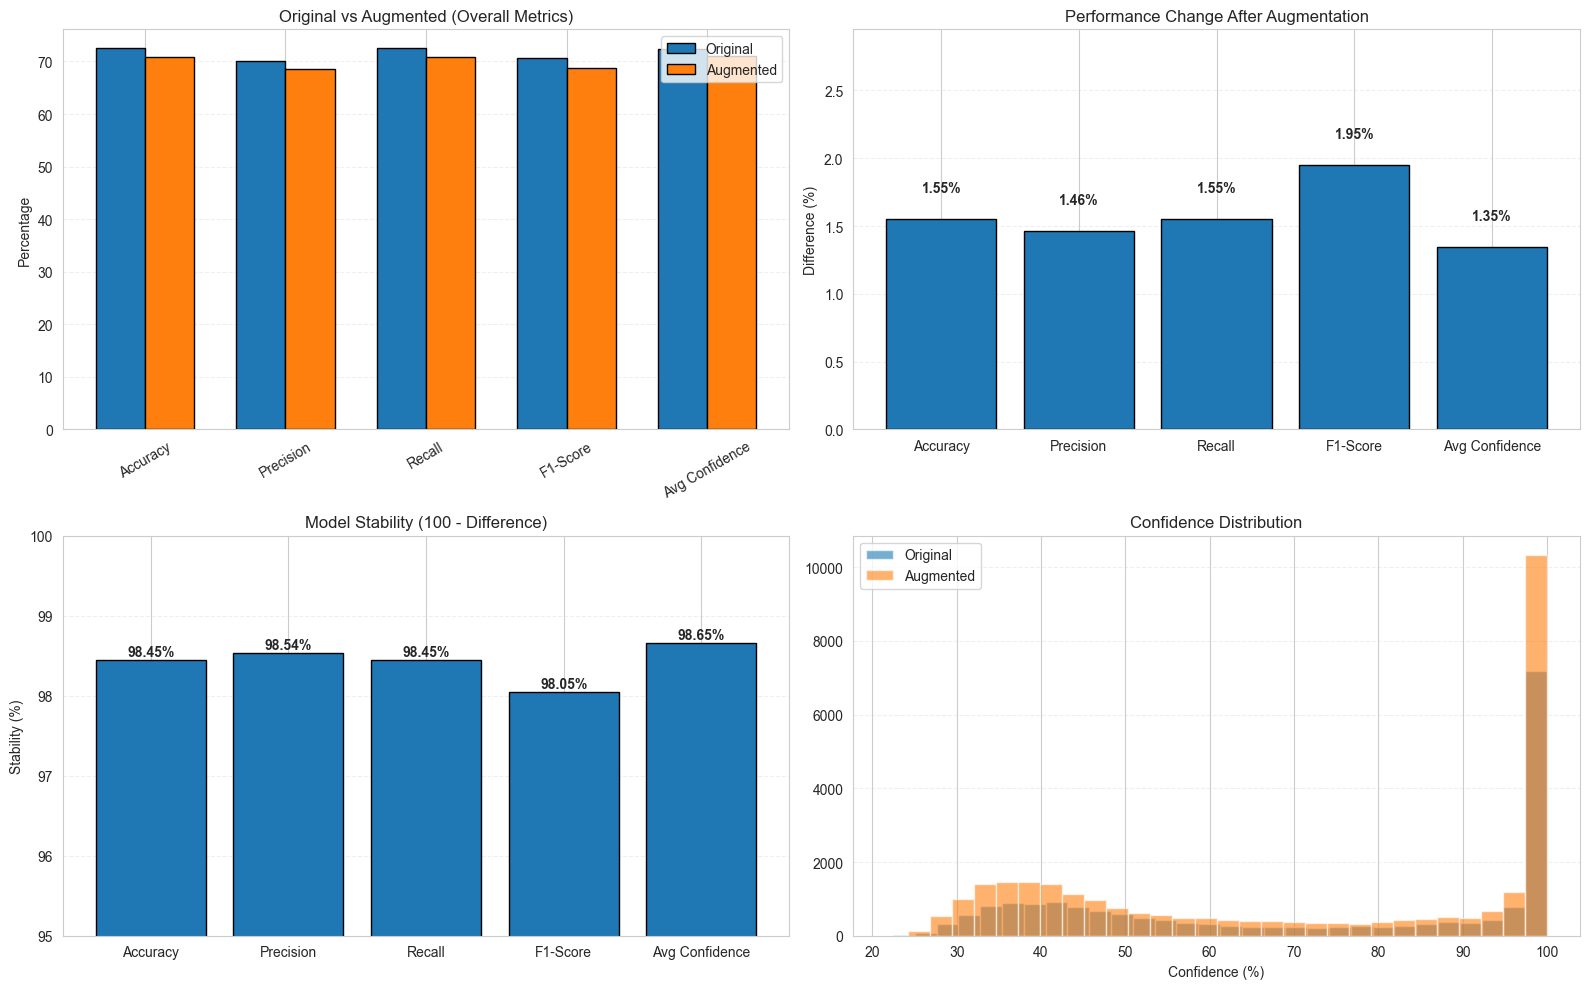


🎯 FINAL SUMMARY
Accuracy: 72.47% → 70.92% | Δ=1.55% | Stability=98.45%
Precision: 70.06% → 68.60% | Δ=1.46% | Stability=98.54%
Recall: 72.47% → 70.92% | Δ=1.55% | Stability=98.45%
F1-Score: 70.67% → 68.72% | Δ=1.95% | Stability=98.05%
Avg Confidence: 72.44% → 71.09% | Δ=1.35% | Stability=98.65%

✅ CELL 4 COMPLETE!


In [20]:
print("\n\n" + "="*100)
print("CELL 4: OVERALL COMPARISON & SUMMARY")
print("="*100)

print("\n📊 OVERALL METRICS COMPARISON TABLE:")
print("="*100)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Avg Confidence']

orig_vals = [
    acc_orig * 100,
    prec_orig * 100,
    recall_orig * 100,
    f1_orig * 100,
    avg_confidence_orig * 100
]

aug_vals = [
    acc_aug * 100,
    prec_aug * 100,
    recall_aug * 100,
    f1_aug * 100,
    avg_confidence_aug * 100
]

diff_vals = [abs(o - a) for o, a in zip(orig_vals, aug_vals)]
stability_vals = [100 - d for d in diff_vals]

overall_comp = pd.DataFrame({
    'Metric': metrics,
    'Original (%)': orig_vals,
    'Augmented (%)': aug_vals,
    'Δ Difference': diff_vals,
    'Stability (100-Δ)': stability_vals
})

display_comp = overall_comp.copy()
for col in ['Original (%)', 'Augmented (%)', 'Δ Difference', 'Stability (100-Δ)']:
    display_comp[col] = display_comp[col].apply(lambda x: f"{x:.2f}")

print(display_comp.to_string(index=False))

print("\n📊 CREATING COMPREHENSIVE VISUALIZATIONS...")
fig = plt.figure(figsize=(16, 10))

ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(metrics))
width = 0.35

ax1.bar(x - width/2, orig_vals, width, label='Original', edgecolor='black')
ax1.bar(x + width/2, aug_vals, width, label='Augmented', edgecolor='black')

ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=30)
ax1.set_ylabel('Percentage')
ax1.set_title('Original vs Augmented (Overall Metrics)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = plt.subplot(2, 2, 2)
ax2.bar(metrics, diff_vals, edgecolor='black')

for i, v in enumerate(diff_vals):
    ax2.text(i, v + 0.2, f"{v:.2f}%", ha='center', fontweight='bold')

ax2.set_ylabel('Difference (%)')
ax2.set_title('Performance Change After Augmentation')
ax2.set_ylim([0, max(diff_vals) + 1])
ax2.grid(axis='y', linestyle='--', alpha=0.3)

ax3 = plt.subplot(2, 2, 3)
ax3.bar(metrics, stability_vals, edgecolor='black')

for i, v in enumerate(stability_vals):
    ax3.text(i, v + 0.05, f"{v:.2f}%", ha='center', fontweight='bold')

ax3.set_ylabel('Stability (%)')
ax3.set_title('Model Stability (100 - Difference)')
ax3.set_ylim([95, 100])
ax3.grid(axis='y', linestyle='--', alpha=0.3)

ax4 = plt.subplot(2, 2, 4)
ax4.hist(confidence_orig * 100, bins=30, alpha=0.6, label='Original')
ax4.hist(confidence_aug * 100, bins=30, alpha=0.6, label='Augmented')

ax4.set_xlabel('Confidence (%)')
ax4.set_title('Confidence Distribution')
ax4.legend()
ax4.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('cell4_overall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*100)
print("🎯 FINAL SUMMARY")
print("="*100)

for i in range(len(metrics)):
    print(f"{metrics[i]}: {orig_vals[i]:.2f}% → {aug_vals[i]:.2f}% | Δ={diff_vals[i]:.2f}% | Stability={stability_vals[i]:.2f}%")

print("\n✅ CELL 4 COMPLETE!")